<a href="https://colab.research.google.com/github/prathmeshk71/Hokage/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

# 1. Load the fashion dataset built straight into TensorFlow
fashion_data = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_data.load_data()

In [ ]:
# 2. Normalize the pixel data (scale images from 0-255 down to 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
# 3. Build a bigger neural network
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)), # Flattens 28x28 images into a long line of pixels
    tf.keras.layers.Dense(128, activation='relu'), # A hidden layer with 128 smart neurons
    tf.keras.layers.Dense(10, activation='softmax') # 10 output neurons (one for each clothing type)
])

In [ ]:
# 4. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 5. Train the model for 5 rounds (epochs)
print("Training the AI to recognize clothes...")
model.fit(x_train, y_train, epochs=5)

Training the AI to recognize clothes...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8251 - loss: 0.4978
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8632 - loss: 0.3780
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8759 - loss: 0.3398
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8841 - loss: 0.3149
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8920 - loss: 0.2951


In [ ]:

# 6. Check how accurate it is on images it has NEVER seen before
print("\nTesting the AI on new images:")
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Accuracy on new clothes: {test_acc * 100:.2f}%")


Testing the AI on new images:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8659 - loss: 0.3707
Accuracy on new clothes: 86.59%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


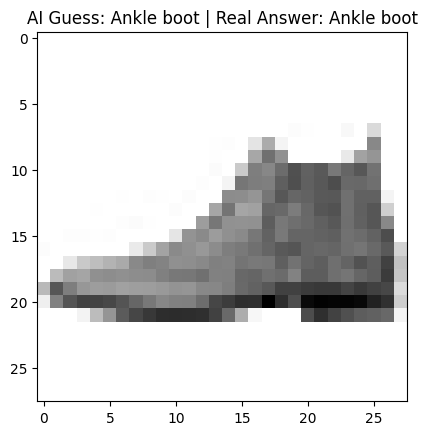

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Choose an image index to look at (change this number to see different items!)
image_index = 0

# Make a prediction for that specific image
predictions = model.predict(x_test[image_index].reshape(1, 28, 28))
predicted_label = np.argmax(predictions)

# Define the label names in order
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dimress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Show the image and what the AI thought it was
plt.figure()
plt.imshow(x_test[image_index], cmap=plt.cm.binary)
plt.title(f"AI Guess: {class_names[predicted_label]} | Real Answer: {class_names[y_test[image_index]]}")
plt.grid(False)
plt.show()